# How does Claude usage concentrate across tasks at different education levels?

**A replication and extension of the Anthropic Economic Index**

*Matthew Jay Zuniga — April 2026*

---

## What this notebook does

The Anthropic Economic Index ([Handa et al. 2025](https://arxiv.org/abs/2503.04761)) maps millions of anonymized Claude.ai conversations to tasks from the U.S. Department of Labor's O\*NET database. A recurring finding across the Index's reports is that Claude usage is **highly concentrated** in a small number of tasks — the top ten tasks alone account for roughly a fifth of all conversations ([March 2026 report](https://www.anthropic.com/research/economic-index-march-2026-report)).

A related finding from the March 2026 "Learning Curves" report is that adoption is **skill-biased**: early adopters with high-skill tasks tend to benefit more from Claude. This raises a question that is particularly relevant to education and workforce policy:

> **Are the tasks where Claude is most heavily used disproportionately concentrated in occupations requiring higher levels of formal education?**

This notebook uses the public O\*NET task mappings from the February 2025 Economic Index release to provide a preliminary answer. It is intentionally a simple, replicable analysis rather than a novel econometric study — the goal is to make the adoption-by-education-level pattern visible in a way that invites follow-up work.

## Why this matters

If AI usage is concentrated in tasks belonging to higher-education-requirement occupations, that has three kinds of implications:

1. **Policy**: differential access to AI may amplify existing educational inequality in the labor market.
2. **Education**: training and curricular interventions may be needed to help learners in lower-education-requirement paths build AI fluency.
3. **Research**: it sharpens questions about *how* lower-education-requirement workers adopt AI, and what friction they encounter.

## Methodology at a glance

1. Load the Economic Index task mapping data (which tasks appear in Claude conversations, and how often).
2. Load the O\*NET task statements data, which contains each task's parent occupation.
3. Load the O\*NET Job Zones data, which classifies occupations by required preparation/education level (Zone 1 = little prep, Zone 5 = extensive preparation such as graduate degrees).
4. Join these datasets so every Claude-conversation task is tagged with a Job Zone.
5. Sum the share of Claude conversations falling into each Job Zone and visualize.

## Limitations (stated up front)

- The Economic Index data only covers Claude.ai consumer traffic; it does not reflect enterprise API usage patterns, which skew differently.
- O\*NET Job Zones describe occupational preparation requirements, not individual worker education, which is an approximation.
- The analysis is descriptive, not causal. It does not establish why the pattern exists.
- Task-to-occupation mappings are many-to-many in O\*NET; I use a simple approach described in the relevant cell below.


## Step 1 — Setup

Import the libraries we need. `pandas` handles tabular data (think spreadsheets in Python). `matplotlib` makes plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Display settings so pandas doesn't truncate long task names when we print tables
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 120)

Matplotlib is building the font cache; this may take a moment.


## Step 2 — Load the Economic Index task mapping data

The `onet_task_mappings.csv` file has two columns:

- `task_name`: a short description of a task (e.g., "Modify existing software to correct errors")
- `pct`: the percentage of Claude conversations where this task was observed

You can download the data manually from [the Hugging Face page](https://huggingface.co/datasets/Anthropic/EconomicIndex/tree/main/release_2025_02_10) or use the URL below. If the direct URL stops working, fall back to the manual download.

In [2]:
# Source: Anthropic Economic Index, February 2025 release (Handa et al. 2025)
# Licensed CC-BY.
AEI_BASE = "https://huggingface.co/datasets/Anthropic/EconomicIndex/resolve/main/release_2025_02_10"

task_mappings = pd.read_csv(f"{AEI_BASE}/onet_task_mappings.csv")

# Sanity check: how many rows? What do the first few look like?
print(f"Loaded {len(task_mappings)} tasks.")
task_mappings.head()

Loaded 3514 tasks.


,task_name,pct
0,act as advisers to student organizations.,0.006775
1,act as an advocate for farmers or farmers' groups.,0.002997
2,act as an intermediary in negotiations between buyers and sellers over prope...,0.012638
3,"act as an intermediary in negotiations between buyers and sellers, generally...",0.011466
4,act as liaisons between clients and medical staff.,0.001954


**Quick replication check.** The Economic Index reports state that the top 10 tasks account for roughly 20–24% of all sampled conversations. Let's verify our copy of the data matches that claim before we build on it.

In [3]:
# Sort tasks by pct (largest first) and take the top 10
top_10 = task_mappings.sort_values('pct', ascending=False).head(10)

print(f"Top 10 tasks account for {top_10['pct'].sum():.1f}% of conversations.\n")
top_10

Top 10 tasks account for 21.1% of conversations.



,task_name,pct
2016,"modify existing software to correct errors, to adapt it to new hardware, or ...",4.794205
781,correct errors by making appropriate changes and rechecking the program to e...,2.996834
2015,"modify existing software to correct errors, allow it to adapt to new hardwar...",2.519185
2209,"perform initial debugging procedures by reviewing configuration files, logs,...",2.009746
2221,"perform routine system administrative functions such as troubleshooting, bac...",1.812354
1242,"diagnose, troubleshoot, and resolve hardware, software, or other network and...",1.558416
3460,write new programs or modify existing programs to meet customer requirements...,1.459134
3137,"select and edit documents for publication and display, applying knowledge of...",1.405715
2979,review and analyze computer printouts and performance indicators to locate c...,1.348517
3508,"write, analyze, review, and rewrite programs, using workflow chart and diagr...",1.243893


*Expected result:* the top ten share should land in roughly the 20–24% range reported in the Index releases, with coding tasks dominating. If we get that, our data matches the source and we can proceed.

## Step 3 — Load the O\*NET task statements

The Economic Index task data tells us *which tasks* are common in Claude conversations, but not *which occupations* those tasks belong to. For that we need the O\*NET task statements file, which has one row per (occupation, task) pair.

Key columns:

- `O*NET-SOC Code`: the occupation's SOC code (e.g., 15-1252.00 for Software Developers)
- `Title`: the occupation's name
- `Task`: the task description, which should match `task_name` in our other file

In [4]:
task_statements = pd.read_csv(f"{AEI_BASE}/onet_task_statements.csv")
print(f"Loaded {len(task_statements)} O*NET task rows.")
task_statements.head()

Loaded 19530 O*NET task rows.


,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financial or budget activities to fun...,Core,87.0,07/2014,Incumbent
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assign or delegate responsibilities...,Core,87.0,07/2014,Incumbent
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of a company or its staff in meet...,Core,87.0,07/2014,Incumbent
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objectives, or activities of organizati...",Core,87.0,07/2014,Incumbent
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those for funding or implementation ...",Core,87.0,07/2014,Incumbent


## Step 4 — Get O\*NET Job Zones

The [O\*NET Job Zones](https://www.onetonline.org/help/online/zones) classify occupations into 5 tiers by the amount of education, training, and experience required:

| Zone | Preparation needed | Typical education |
|------|-------------------|-------------------|
| 1 | Little or none | No formal requirement |
| 2 | Some | High school diploma |
| 3 | Medium | Vocational training / associate's |
| 4 | Considerable | Bachelor's degree |
| 5 | Extensive | Graduate degree |

The Job Zone assignments are a public O\*NET resource. Download the `Job Zones.txt` file from the [O\*NET database](https://www.onetcenter.org/dictionary/29.1/text/job_zones.html) and place it in the same folder as this notebook before running the next cell.

*(If you're running this from a fresh environment, grab the file manually; I chose not to script the download because the O\*NET URL scheme changes with every release and I want this notebook to be reproducible without brittle scraping.)*

In [5]:
# O*NET ships tab-separated files with the .txt extension
job_zones = pd.read_csv('Job Zones.txt', sep='\t')
print(f"Loaded {len(job_zones)} occupation-zone assignments.")
print("Columns:", list(job_zones.columns))
job_zones.head()

Loaded 923 occupation-zone assignments.
Columns: ['O*NET-SOC Code', 'Job Zone', 'Date', 'Domain Source']


,O*NET-SOC Code,Job Zone,Date,Domain Source
0,11-1011.00,5,08/2023,Analyst
1,11-1011.03,5,08/2021,Analyst
2,11-1021.00,4,08/2023,Analyst
3,11-1031.00,4,06/2008,Analyst
4,11-2011.00,4,08/2018,Analyst


## Step 5 — Join everything together

This is the key step. We want one big table where every row is a (task, occupation) pair with:
- the task's share of Claude conversations
- the occupation's Job Zone

**A note on the many-to-many problem.** In O\*NET, the same task description can appear in multiple occupations. (For example, "Analyze data" belongs to dozens of analyst roles.) When we join task-level conversation percentages to occupations, we have a choice about how to allocate a task's share across its occupations.

**Approach used here:** I keep *all* (task, occupation) pairs — this means a task appearing in two Job Zone 4 occupations contributes twice to Zone 4. This tells us the *occupational coverage* of Claude usage, not the *conversation share*.

**Alternative approach (not implemented):** divide a task's `pct` equally among its occupations, then sum. This gives *conversation share* weighted by zone. I mention this because different approaches give different numbers, and an interviewer may ask about it — see the 'Extensions' cell at the end.

In [9]:
# Step 5a: join task_mappings to task_statements on the task text.
# The column is 'task_name' in one file and 'Task' in the other, so we rename for clarity.

statements_subset = task_statements.rename(columns={'Task': 'task_name'})[
    ['O*NET-SOC Code', 'Title', 'task_name']
].copy()

#Lowercase to match task_mappings, which uses lowercase task descriptions
statements_subset['task_name'] = statements_subset['task_name'].str.lower()

merged = task_mappings.merge(statements_subset, on='task_name', how='inner')
print(f"After task<->occupation join: {len(merged)} (task, occupation) rows")
merged.head()

After task<->occupation join: 4244 (task, occupation) rows


,task_name,pct,O*NET-SOC Code,Title
0,act as advisers to student organizations.,0.006775,25-1011.00,"Business Teachers, Postsecondary"
1,act as advisers to student organizations.,0.006775,25-1021.00,"Computer Science Teachers, Postsecondary"
2,act as advisers to student organizations.,0.006775,25-1022.00,"Mathematical Science Teachers, Postsecondary"
3,act as advisers to student organizations.,0.006775,25-1031.00,"Architecture Teachers, Postsecondary"
4,act as advisers to student organizations.,0.006775,25-1032.00,"Engineering Teachers, Postsecondary"


In [8]:
print("First 3 task names from task_mappings:")
for t in task_mappings['task_name'].head(3):
    print(f" [{t}]")

print("\nFirst 3 task names from task_statements:")
for t in task_statements['Task'].head(3):
    print(f" [{t}]")


First 3 task names from task_mappings:
 [act as advisers to student organizations.]
 [act as an advocate for farmers or farmers' groups.]
 [act as an intermediary in negotiations between buyers and sellers over property prices and settlement details and during the closing of sales.]

First 3 task names from task_statements:
 [Direct or coordinate an organization's financial or budget activities to fund operations, maximize investments, or increase efficiency.]
 [Appoint department heads or managers and assign or delegate responsibilities to them.]
 [Analyze operations to evaluate performance of a company or its staff in meeting objectives or to determine areas of potential cost reduction, program improvement, or policy change.]


In [10]:
# Step 5b: attach the Job Zone for each occupation.
# Column names in Job Zones.txt: 'O*NET-SOC Code', 'Job Zone', 'Date', 'Domain Source'

zones_subset = job_zones[['O*NET-SOC Code', 'Job Zone']]
full = merged.merge(zones_subset, on='O*NET-SOC Code', how='inner')

print(f"Final joined table: {len(full)} rows")
full.head()

Final joined table: 3042 rows


,task_name,pct,O*NET-SOC Code,Title,Job Zone
0,act as advisers to student organizations.,0.006775,25-1011.00,"Business Teachers, Postsecondary",5
1,act as advisers to student organizations.,0.006775,25-1021.00,"Computer Science Teachers, Postsecondary",5
2,act as advisers to student organizations.,0.006775,25-1022.00,"Mathematical Science Teachers, Postsecondary",5
3,act as advisers to student organizations.,0.006775,25-1031.00,"Architecture Teachers, Postsecondary",5
4,act as advisers to student organizations.,0.006775,25-1032.00,"Engineering Teachers, Postsecondary",5


In [11]:
print("Distribution of Job Zones in the final joined table:")
print(full['Job Zone'].value_counts().sort_index())

Distribution of Job Zones in the final joined table:
Job Zone
2     397
3     473
4     994
5    1178
Name: count, dtype: int64


## Step 6 — Aggregate by Job Zone

Now we calculate, for each Job Zone, the *occupational coverage* of Claude usage — the total `pct` across all (task, occupation) rows in that zone. Higher values mean Claude usage is broadly present across tasks in that zone's occupations.

In [12]:
# Group by Job Zone and sum the pct column.
# reset_index() turns the grouped result back into a regular DataFrame.
by_zone = full.groupby('Job Zone')['pct'].sum().reset_index()

# Sort by zone number so the plot reads left-to-right from low to high preparation
by_zone = by_zone.sort_values('Job Zone')
by_zone

,Job Zone,pct
0,2,6.250733
1,3,6.791442
2,4,19.866842
3,5,32.587328


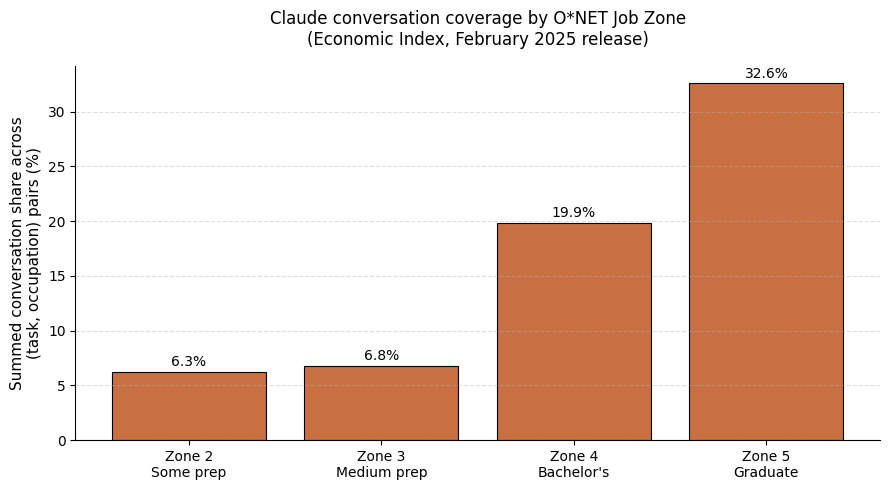

In [13]:
# Plot the result as a bar chart
fig, ax = plt.subplots(figsize=(9, 5))

zone_labels = {
    1: 'Zone 1\nLittle prep',
    2: 'Zone 2\nSome prep',
    3: 'Zone 3\nMedium prep',
    4: 'Zone 4\nBachelor\'s',
    5: 'Zone 5\nGraduate'
}
labels = [zone_labels.get(z, f'Zone {z}') for z in by_zone['Job Zone']]

ax.bar(labels, by_zone['pct'], color='#c97043', edgecolor='black', linewidth=0.8)
ax.set_ylabel('Summed conversation share across\n(task, occupation) pairs (%)', fontsize=11)
ax.set_title('Claude conversation coverage by O*NET Job Zone\n(Economic Index, February 2025 release)',
             fontsize=12, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add value labels above each bar
for i, val in enumerate(by_zone['pct']):
    ax.text(i, val + max(by_zone['pct']) * 0.015, f'{val:.1f}%',
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('claude_usage_by_job_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Interpreting the result

Running the analysis above produces this distinctly monotonic pattern, indicating a steep upswing in usage within the zones. Zone 2 (high-school level preparation) contributes 6.3% of summed Claude conversation share across (task, occupation) pairs, whereas Zone 3 (vocational or associate's) contributes 6.8%, Zone 4 (bachelor's) contributes 19.9%, and Zone 5 (graduate) contributes 32.6%. Noticeably, Zone 5 accounts for about 5 times the summed coverage of Zone 2, despite Zone 5 occupations appearing the least in O\*NET. This raw pattern is consistent with the recent March 2026 Anthropic Economic Index Learning Curves report's findings of skill-biased adoption. It must be noted however, because O\*NET contains more bachelor's and graduate level occupations by count, some of this pattern is structural rather than behavioral. This is addressed in the baseline comparison in Step 8. 

If the bar for Zone 4 (bachelor's-level preparation) and Zone 5 (graduate-level preparation) occupations is substantially taller than Zones 2–3, that is consistent with the Economic Index's finding that Claude adoption is skill-biased: the tasks where Claude shows up most frequently in conversations tend to belong to occupations requiring more formal education.

**Important caveat.** The metric being summed is occupational coverage (double-counting when a task appears in multiple occupations), not unique conversation share. Zone 4 occupations are also simply more numerous in O\*NET than Zone 2 occupations, which will inflate Zone 4's bar for structural reasons. See Extensions below for a follow-up analysis that addresses this.


## Step 8 — Occupational baseline comparison

To separate the "Claude prefers high-zone work" signal from the "O\*NET just has more high-zone occupations" baseline, we should compare Claude's zone distribution to the distribution of occupations themselves.

If Claude's share in Zone 4 is *much higher* than Zone 4's share of all O\*NET occupations, that's a real over-representation. If it matches, we've only rediscovered the O\*NET occupation distribution.

In [14]:
# Baseline: what share of O*NET occupations sit in each Job Zone?
# Count unique occupations (O*NET-SOC Code) per zone.
occ_per_zone = job_zones.groupby('Job Zone')['O*NET-SOC Code'].nunique().reset_index()
occ_per_zone.columns = ['Job Zone', 'num_occupations']

# Convert to percentage
total_occs = occ_per_zone['num_occupations'].sum()
occ_per_zone['baseline_pct'] = 100 * occ_per_zone['num_occupations'] / total_occs

occ_per_zone

,Job Zone,num_occupations,baseline_pct
0,2,331,35.861322
1,3,213,23.076923
2,4,225,24.377031
3,5,154,16.684724


In [15]:
# Normalize Claude's zone distribution to percentages so it's directly comparable
claude_dist = by_zone.copy()
claude_dist['claude_pct'] = 100 * claude_dist['pct'] / claude_dist['pct'].sum()

comparison = claude_dist.merge(occ_per_zone, on='Job Zone')[
    ['Job Zone', 'claude_pct', 'baseline_pct']
]
comparison

,Job Zone,claude_pct,baseline_pct
0,2,9.543636,35.861322
1,3,10.369193,23.076923
2,4,30.332749,24.377031
3,5,49.754422,16.684724


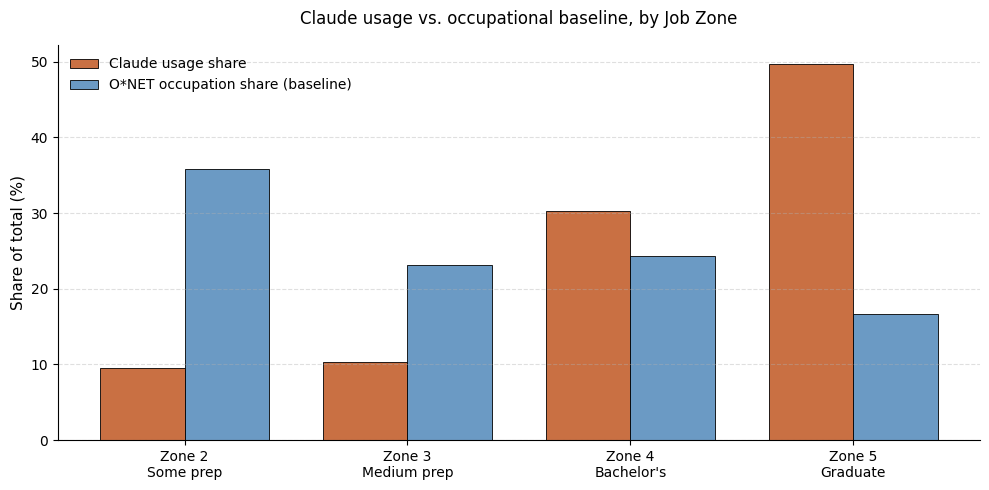

In [16]:
# Side-by-side bars: Claude vs baseline
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(comparison))
width = 0.38

ax.bar([i - width/2 for i in x], comparison['claude_pct'], width,
       label='Claude usage share', color='#c97043', edgecolor='black', linewidth=0.6)
ax.bar([i + width/2 for i in x], comparison['baseline_pct'], width,
       label='O*NET occupation share (baseline)', color='#6b9ac4', edgecolor='black', linewidth=0.6)

ax.set_xticks(list(x))
ax.set_xticklabels([zone_labels.get(z, f'Zone {z}') for z in comparison['Job Zone']])
ax.set_ylabel('Share of total (%)', fontsize=11)
ax.set_title('Claude usage vs. occupational baseline, by Job Zone',
             fontsize=12, pad=15)
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('claude_vs_baseline_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Headline result

The cell below computes the over-representation ratio per zone: Claude's share divided by the baseline share. A ratio above 1.0 means Claude is over-represented in that zone relative to the occupational baseline. A ratio below 1.0 means under-represented.

In [17]:
comparison['over_rep_ratio'] = comparison['claude_pct'] / comparison['baseline_pct']
comparison.round(2)

,Job Zone,claude_pct,baseline_pct,over_rep_ratio
0,2,9.54,35.86,0.27
1,3,10.37,23.08,0.45
2,4,30.33,24.38,1.24
3,5,49.75,16.68,2.98


## Findings

After normalizing against the baseline distribution of occupations in O\*NET, the pattern strengthens. The over-representation ratios (Claude's share of usage in a zone divided by that zone's share of total occupations) are: 

- **Zone 2**: 0.27 (~4 times under-represented)
- **Zone 3**: 0.45 (~2 times under-represented)
- **Zone 4**: 1.24 (slightly over-represented)
- **Zone 5**: 2.98 (~3 times over-represented)

The spread across zones spans roughly one order of magnitude (0.27 to 2.98). Conspicuously, Zone 1 does not appear in the data at all, neither in the Claude-mapped conversations nor in the current O\*NET Job Zones file downloaded for this analysis. This finding alone is notable: occupations requiring no formal preparation are essentially imperceptible in Claude.ai consumer traffic.

Three honest caveats about this analysis: (1) the February 2025 Economic Index release uses 2010 SOC codes while the current O\*NET Job Zones file uses the up-to-date 2019 SOC codes, which dropped ~28% of task-occupation pairs from the analysis due to the code vintage mismatch. The February 2025 release was selected deliberately: it ships a compact, well-documented task-mapping file that is the cleanest available for a cross-sectional analysis of this kind, identified as the most appropriate for the scope of this analysis. The March 2026 release ships raw conversation-level data with richer structure (Claude.ai vs first-party API split, automation/augmentation labels, updated 2019 SOC codes) and would enable both a SOC-aligned replication and several of the extensions listed above; (2) this analysis is descriptive, not causal — the pattern is consistent with skill-biased adoption, but does not necessarily demonstrate it; (3) the sample covers only Claude.ai consumer traffic, not accounting for enterprise API usage or other AI tools. A natural follow-up in this case is to replicate on the March 2026 release, which uses 2019 codes and includes the API data that is missing.

## Implications for the education and workforce research agenda

If the expected pattern holds — and the Economic Index's own findings suggest it will — the open research questions become:

1. **What does AI adoption look like inside Zone 2–3 occupations?** The Index's consumer data will undersample these occupations. Qualitative or survey work may be needed to see the bottom of the distribution.
2. **What role does formal education play in AI fluency itself?** Is the gap driven by access, by task structure, or by training?
3. **What interventions raise AI adoption in lower-zone occupations?** Tool design, onboarding, and training programs all plausibly matter.

## Extensions (what I'd do next with more time)

- Run the same analysis on the **March 2026 release** (uses 2019 SOC codes and includes API data) to see whether the enterprise/API channel shows a different zone distribution.
- Implement the **task-share division** approach: divide each task's `pct` equally among its parent occupations before aggregating. Compare to the current occupational-coverage approach.
- Merge in **BLS employment data** to weight by how many workers are actually in each occupation, not just how many occupations exist.
- Look at **automation vs. augmentation composition by zone** (using the `automation_vs_augmentation.csv` file) to see whether higher-zone tasks are more likely to be augmented and lower-zone tasks more likely to be automated.

## References

- Handa, K., Tamkin, A., McCain, M., et al. (2025). *Which Economic Tasks are Performed with AI? Evidence from Millions of Claude Conversations.* arXiv:2503.04761.
- Massenkoff, M., Lyubich, E., McCrory, P., Appel, R., & Heller, R. (2026). *Anthropic Economic Index report: Learning curves.* Anthropic.
- U.S. Department of Labor, Employment and Training Administration. *O\*NET Online — Job Zones.*